# TensorFlow를 활용한 로지스틱 회귀 실습

이 노트북에서는 TensorFlow를 사용하여 간단한 로지스틱 회귀문제를 풀어봅니다.
여기서는 iris 데이터셋을 사용하여 꽃의 종류를 분류하는 예제를 다룹니다.

## 주요 단계
1. 데이터 불러오기 및 전처리
2. 모델 정의 (Dense Layer)
3. 손실 함수 및 최적화 방법 설정
4. 학습 진행 및 시각화


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print(tf.__version__)


2.20.0


## 1. 데이터 불러오기 및 전처리

In [2]:
iris = load_iris()
X = iris.data[:, :2]
y = (iris.target == 0).astype(np.float32)

print("X shape:", X.shape, "y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X shape: (150, 2) y shape: (150,)


## 2. 모델 정의

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 모델 컴파일
- 손실 함수: MSE (Mean Squared Error)
- 최적화 방법: SGD (Stochastic Gradient Descent)

In [4]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])


## 4. 모델 학습

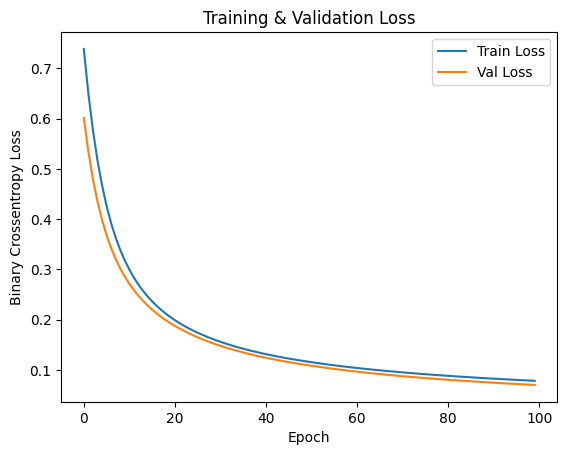

In [5]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_data=(X_test, y_test),
                    verbose=0)

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.show()


## 5. 결과 확인

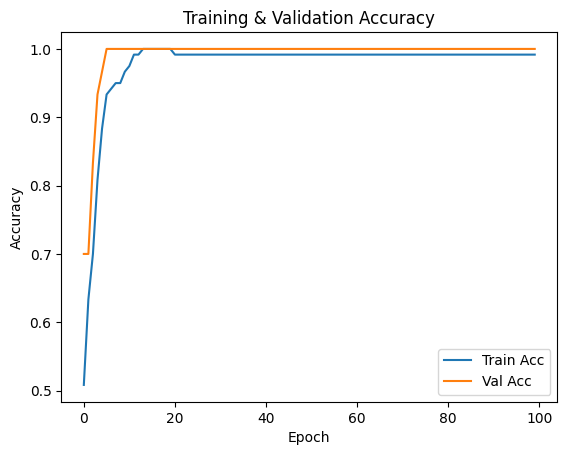

테스트 정확도: 1.000


In [6]:
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.show()

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"테스트 정확도: {acc:.3f}")


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


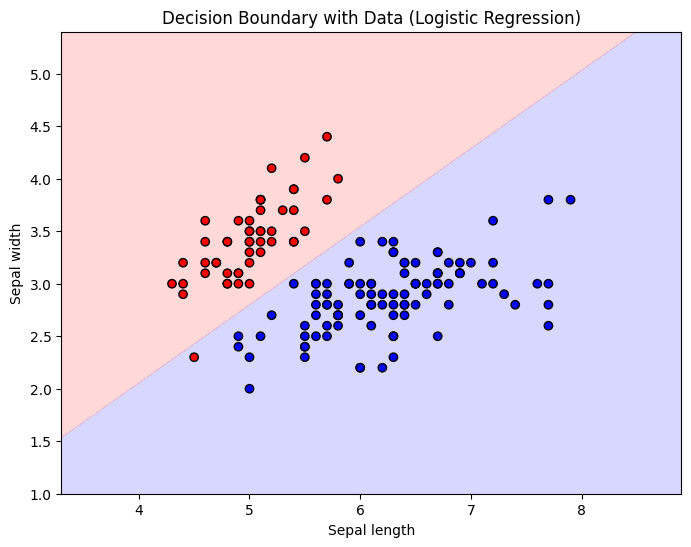

In [7]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
grid = scaler.transform(grid)
probs = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.3, cmap="bwr")

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Decision Boundary with Data (Logistic Regression)")
plt.show()


## 생각해보기
- 로지스틱 회귀 모델과 선형 회귀 모델의 차이는?

선형 회귀는 실수 전체 범위의 연속값(예: 가격, 온도)을 예측하며 손실 함수로 MSE를 사용합니다. 로지스틱 회귀는 출력층에 시그모이드 활성화 함수를 붙여 결과를 0~1 사이의 확률로 바꾼 뒤 분류 문제(예: Setosa vs 그 외)를 풀며, 손실 함수로 binary crossentropy를 사용합니다. 이번 실습에서도 시그모이드 출력을 기준으로 결정 경계를 그려 두 클래스를 나눴습니다.

- Learning Rate(학습률)의 역할은 무엇인가요?
- 너무 크거나 너무 작은 학습률을 사용하면 어떤 일이 발생하나?

학습률은 경사하강법에서 가중치를 한 번에 얼마나 크게 업데이트할지 정하는 값입니다. 너무 크면 손실이 진동하거나 발산해 최적점을 지나쳐 버리고, 너무 작으면 수렴이 지나치게 느려지거나 지역 최솟값 근처에서 학습이 거의 멈춰버립니다. 이번 실습에서는 학습률 0.1로 100 epoch 만에 테스트 정확도 100%에 도달했습니다.